# TDS forward and inverse: extending the spectral toolkit

In `permeation_compare.ipynb` we showed that the Chebyshev pseudospectral
solver in `chebyshev_festim.py` converges geometrically on the gas-driven
permeation problem and beats FESTIM P1, P2, and P3 on a matched-accuracy
basis — exponential vs. algebraic convergence is a hard trend to argue
with when the underlying solution is smooth in the bulk. This notebook
extrapolates the same tools to a new use case: **thermal desorption
spectroscopy (TDS)** of a tungsten foil with two McNabb–Foster traps.

TDS is harder for Chebyshev than permeation was. The implantation source
is a Gaussian centred at $4.5\,\mathrm{nm}$ with a $2.5\,\mathrm{nm}$
standard deviation, sitting inside a $20\,\mathrm{\mu m}$ foil — a
width-to-domain ratio of $\sim 10^{-4}$. A plain Chebyshev–Lobatto grid
clusters nodes at *both* ends of the interval, but here the action is
only at the left end; half of the spectral budget is wasted near
$x = L$. Uniform-cell FEM has the same problem on the opposite side: to
put even ten cells inside the source FWHM you would need on the order of
$10^5$ cells.

The fix is the same idea on both sides: cluster nodes near $x = 0$.
For the spectral solver we use the **sinh-stretched** mapping that
`ChebyshevMesh1D` already supports (`left_stretch>0`); for FESTIM we use
the **graded mesh** with three vertex blocks (~200 in $[0, 30\,\mathrm{nm}]$,
~300 in $[30\,\mathrm{nm}, 3\,\mathrm{\mu m}]$, ~200 in $[3\,\mathrm{\mu m}, L]$).
Once both solvers are configured fairly, we can:

1. Sweep both at increasing refinement and plot relative-L2 error vs.
   degrees of freedom and vs. forward-solve wall time. The "ground truth"
   here is a spectrally-converged Chebyshev reference at $N+1 = 193$,
   playing the role of the analytical Crank reference from the
   permeation notebook (no closed-form TDS solution exists, so we lean
   on the Richardson-style argument that geometric convergence makes
   the high-$N$ run an extrapolation-grade reference).
2. Pick the first refinement of each method strictly below
   $10^{-2}$ relative-L2 error and use those meshes for an inverse
   problem: recover the four trap parameters $(n_1, n_2, E_{p,1}, E_{p,2})$
   from a noisy synthetic TDS spectrum with Levenberg–Marquardt.
3. Plot the LM convergence trajectory — relative parameter error vs.
   cumulative forward-solve wall time — for both methods on the same
   axes. This is the inverse-problem analogue of the per-call Pareto
   plot in `permeation_compare.ipynb`.


## 1. Imports and constants

`chebyshev_festim` is the in-repo Chebyshev pseudospectral solver. It
mirrors FESTIM's public API (`HydrogenTransportProblem`, `Material`,
`Species`, `Reaction`, `SurfaceFlux`, ...) so user code reads almost
identically to a FESTIM run.


In [1]:
import os
import time
import contextlib
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import chebyshev_festim as CF


### 1.1 Physical constants and the workshop tutorial parameters

These match the FESTIM workshop "TDS for tungsten" tutorial verbatim.
Quantities are in SI units, with concentrations in mol/m³ throughout
(divide by Avogadro to convert atoms → mol).

`THETA_TRUE` is the parameter vector the inverse problem will try to
recover from the noisy desorption flux: $(n_1, n_2, E_{p,1}, E_{p,2})$.


In [2]:
# physical constants
AVOGADRO = 6.02214076e23          # 1/mol
W_DENSITY = 6.3e28                # tungsten atoms / m^3
K_B_EV = 8.617333262145e-5        # eV / K

# tutorial geometry and TDS protocol
L = 20e-6                         # foil thickness (m)
IMPLANT_TIME = 400.0              # s, implantation duration
INCIDENT_FLUX = 2.5e19 / AVOGADRO # mol/m^2/s, ion flux during implantation
CENTER, WIDTH = 4.5e-9, 2.5e-9    # m, Gaussian source: mean and std-dev
T_IMPLANT = 300.0                 # K, holding temperature pre-TDS
T_RAMP = 6.0                      # K/s, TDS ramp rate
START_TDS = IMPLANT_TIME + 50.0   # s, ramp begins at t=450
FINAL_TIME = 500.0                # s, end of simulation

# true trap parameters (the targets of the inverse problem)
N1_TRUE, N2_TRUE = 1.3e-3, 4e-4   # site fractions (dimensionless)
E1_TRUE, E2_TRUE = 0.87, 1.0      # detrapping activation energies (eV)
THETA_TRUE = np.array([N1_TRUE, N2_TRUE, E1_TRUE, E2_TRUE])

# Sinh-stretch alpha for the Chebyshev mesh: bigger -> nodes pile up more
# aggressively near x=0 where the Gaussian source lives. alpha=6 keeps a
# meaningful cluster near the source while leaving enough bulk nodes for
# the trapped-H profile that develops during the TDS ramp -- more extreme
# values (e.g. alpha=8 or 9) over-cluster and the sweep stops converging
# in the tested N range.
LEFT_STRETCH = 6.0

# trapping prefactor: 4.1e-7 / (1.1e-10^2 * 6 * w_atom_density_in_mol_per_m3).
# this is the standard McNabb-Foster expression for nu_m as used by FESTIM.
K0_TRAP = 4.1e-7 / (1.1e-10**2 * 6 * (W_DENSITY / AVOGADRO))

# all figures from this notebook land here
FIG_DIR = os.path.join("..", "figs")
os.makedirs(FIG_DIR, exist_ok=True)
print("figures will be written to", os.path.abspath(FIG_DIR))


figures will be written to /Users/colinweaver/Documents/MIT Documents/18.336/18336Project/figs


## 2. Why TDS is harder for both methods

The Gaussian implantation source has FWHM $\approx 2.355 \cdot 2.5\,
\mathrm{nm} \approx 5.9\,\mathrm{nm}$, which sits inside a $20\,
\mathrm{\mu m}$ domain. That is four orders of magnitude separation
between the source scale and the domain scale. A plain Chebyshev–
Lobatto grid clusters nodes at the endpoints with spacing
$\Delta x_\min \sim L/N^2$, but it clusters at *both* ends. At $N = 64$
the tightest spacing is about $4.9\,\mathrm{nm}$, comparable to the
source width — but only at $x=0$ and $x=L$, and we only need
resolution at $x=0$. A uniform FEM mesh wastes resolution everywhere
except inside the source. Both methods need an asymmetric clustering
strategy.

The fix on the spectral side is the **sinh-stretched** mapping that
`ChebyshevMesh1D` already supports:
$$
x(s) = x_\min + (x_\max - x_\min) \, \frac{\sinh(\alpha\, s)}{\sinh \alpha},
\qquad s \in [0, 1],
$$
with $\alpha = $`LEFT_STRETCH` $= 6$. This pushes the cluster of nodes toward $x = 0$
without introducing a singular Jacobian. The fix on the FEM side is the
three-block **graded mesh** built into `run_festim_tds`: ~200 vertices
in the first $30\,\mathrm{nm}$, ~300 in $[30\,\mathrm{nm}, 3\,
\mathrm{\mu m}]$, ~200 in $[3\,\mathrm{\mu m}, L]$. The next cell
shows what both meshes actually look like overlaid on the source
profile.


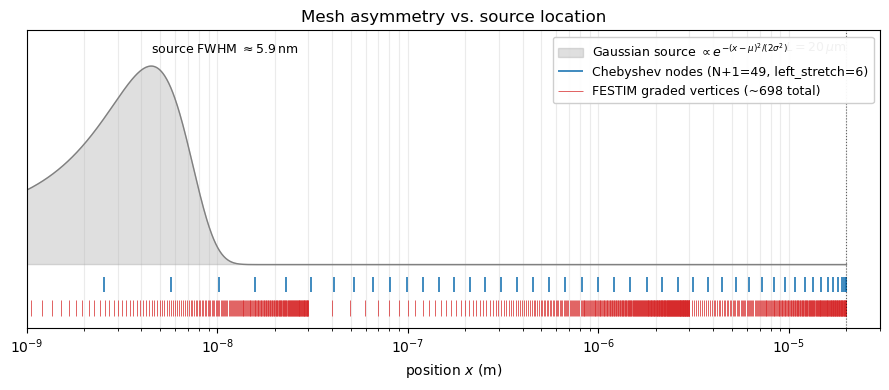

nodes/vertices inside source FWHM (5.9 nm wide):
  Chebyshev (N+1=49, sinh-stretched): 2
  FESTIM    (graded, scale=1.0)      : 39


In [3]:
# Mesh-and-source visualisation: why we cluster nodes near x=0.
# Top: filled grey Gaussian source profile (normalised).
# Middle ticks: sinh-stretched Chebyshev nodes (N=48, left_stretch=LEFT_STRETCH).
# Bottom ticks: FESTIM graded mesh vertices at scale=1.0.
# log-x so the 5.9 nm FWHM and the 20 um domain are both visible.

# Chebyshev mesh
cheb_mesh_viz = CF.ChebyshevMesh1D(N=48, x_max=L, left_stretch=LEFT_STRETCH)
cheb_x = np.asarray(cheb_mesh_viz.x)
cheb_x_pos = cheb_x[cheb_x > 0]  # log-x can't show x=0; flag it separately

# FESTIM graded vertices, same construction as run_festim_tds at scale=1.0
n_a, n_b, n_c = 200, 300, 200
fes_x = np.concatenate([
    np.linspace(0, 30e-9,    num=n_a),
    np.linspace(30e-9, 3e-6, num=n_b)[1:],
    np.linspace(3e-6, L,     num=n_c)[1:],
])
fes_x_pos = fes_x[fes_x > 0]

# Gaussian source profile, normalised so the peak sits at 1
xx = np.geomspace(1e-10, L, 2000)
g = np.exp(-0.5 * ((xx - CENTER) / WIDTH) ** 2)

fig, ax = plt.subplots(figsize=(9, 4.0))

# source profile
ax.fill_between(xx, 0, g, color="grey", alpha=0.25,
                label=r"Gaussian source $\propto e^{-(x - \mu)^2/(2\sigma^2)}$")
ax.plot(xx, g, color="grey", lw=1.0)

# Chebyshev node ticks (just above the source baseline)
y_cheb = -0.10
ax.vlines(cheb_x_pos, y_cheb - 0.04, y_cheb + 0.04,
          color="C0", lw=1.2, label=f"Chebyshev nodes (N+1=49, left_stretch={LEFT_STRETCH:g})")

# FESTIM vertex ticks (further below)
y_fes = -0.22
ax.vlines(fes_x_pos, y_fes - 0.04, y_fes + 0.04,
          color="C3", lw=0.6, alpha=0.85,
          label=f"FESTIM graded vertices (~{len(fes_x)} total)")

# domain endpoints
ax.axvline(L, color="k", ls=":", lw=0.8, alpha=0.6)
ax.text(L, 1.05, r"$L = 20\,\mu\mathrm{m}$", ha="right", va="bottom", fontsize=9)
ax.text(CENTER, 1.05, r"source FWHM $\approx 5.9\,\mathrm{nm}$",
        ha="left", va="bottom", fontsize=9)

ax.set_xscale("log")
ax.set_xlim(1e-9, L * 1.5)
ax.set_ylim(-0.32, 1.18)
ax.set_xlabel("position $x$ (m)")
ax.set_yticks([])
ax.set_title("Mesh asymmetry vs. source location")
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.25, which="both", axis="x")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tds_mesh_source.pdf"), bbox_inches="tight")
plt.show()

# how many nodes/vertices actually fall inside the source FWHM (~ +/- 2.94 nm)
fwhm = 2.355 * WIDTH
in_fwhm_lo, in_fwhm_hi = CENTER - 0.5 * fwhm, CENTER + 0.5 * fwhm
n_cheb_in = int(((cheb_x >= in_fwhm_lo) & (cheb_x <= in_fwhm_hi)).sum())
n_fes_in = int(((fes_x >= in_fwhm_lo) & (fes_x <= in_fwhm_hi)).sum())
print(f"nodes/vertices inside source FWHM ({fwhm*1e9:.1f} nm wide):")
print(f"  Chebyshev (N+1=49, sinh-stretched): {n_cheb_in}")
print(f"  FESTIM    (graded, scale=1.0)      : {n_fes_in}")


## 3. The two forward solvers

Both solvers integrate the same physics — one mobile species, two
McNabb–Foster traps, Gaussian source gated by `t <= IMPLANT_TIME`,
piecewise temperature schedule — with backward Euler under matched
controllers (`max_stepsize = 0.5\,\mathrm{s}`, milestones at
`IMPLANT_TIME`, `START_TDS`, and `START_TDS + 50`). They differ only in
the spatial discretisation.

* **FESTIM (P1).** Three-block graded mesh, scaled uniformly by
  `mesh_scale`. The first block puts ~200 vertices in $[0, 30\,
  \mathrm{nm}]$ at `mesh_scale = 1.0` to resolve the source.
* **Chebyshev pseudospectral.** `ChebyshevMesh1D(N, x_max=L,
  left_stretch=LEFT_STRETCH)` (with `LEFT_STRETCH = 6.0`) builds the sinh-stretched grid; differentiation
  matrices $D, D^2$ are precomputed once at construction time and
  reused across every backward-Euler step (and across every LM
  forward call).


In [4]:
def run_festim_tds(n1, n2, E1, E2, mesh_scale=1.0, _timings=None):
    '''FESTIM forward solve at the four trap parameters.

    Returns (t, flux_total) where flux_total = flux_left + flux_right.
    Mirrors the workshop tutorial structure, line for line.

    mesh_scale (default 1.0) multiplies the three graded-block vertex
    counts uniformly. scale=1.0 reproduces the tutorial mesh
    (~700 vertices: 200 in [0, 30 nm], 300 in [30 nm, 3 um],
    200 in [3 um, L]); scale=0.5 ~ 350 vertices, scale=2.0 ~ 1400.

    If _timings is a dict, it is filled with three keys:
      - 'setup'  : my.initialise() time (mesh + form compilation cache lookup
                   + matrix preallocation).
      - 'newton' : accumulated time spent inside my.solver.solve across all
                   backward-Euler steps. This is the "honest" numerical
                   work — it scales with the spatial discretisation.
      - 'solve'  : my.run() wall time. Includes Newton plus per-step
                   SurfaceFlux post-processing, which a profile shows is
                   dominated by FFCx JIT cache directory scans (the form is
                   rebuilt each timestep). Independent of mesh resolution,
                   so it inflates the apparent cost of FESTIM relative to
                   Chebyshev unfairly.

    For comparison plots (Pareto, LM trajectory) prefer 'newton';
    'solve' is reported alongside for context.
    '''
    import festim as F
    import ufl

    my = F.HydrogenTransportProblem()

    n_a = max(int(round(200 * mesh_scale)), 8)
    n_b = max(int(round(300 * mesh_scale)), 12)
    n_c = max(int(round(200 * mesh_scale)), 8)
    vertices = np.concatenate([
        np.linspace(0, 30e-9,    num=n_a),
        np.linspace(30e-9, 3e-6, num=n_b)[1:],
        np.linspace(3e-6, L,     num=n_c)[1:],
    ])
    my.mesh = F.Mesh1D(vertices)

    tungsten = F.Material(D_0=4.1e-7, E_D=0.39)
    vol = F.VolumeSubdomain1D(id=1, borders=[0, L], material=tungsten)
    left = F.SurfaceSubdomain1D(id=2, x=0)
    right = F.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = F.Species("H")
    t1 = F.Species("trapped_H1", mobile=False)
    t2 = F.Species("trapped_H2", mobile=False)
    e1 = F.ImplicitSpecies(n=float(n1) * W_DENSITY / AVOGADRO, others=[t1])
    e2 = F.ImplicitSpecies(n=float(n2) * W_DENSITY / AVOGADRO, others=[t2])
    my.species = [H, t1, t2]

    my.reactions = [
        F.Reaction(reactant=[H, e1], product=[t1],
                   k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E1), volume=vol),
        F.Reaction(reactant=[H, e2], product=[t2],
                   k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E2), volume=vol),
    ]

    def ion_flux(t):
        return ufl.conditional(t <= IMPLANT_TIME, INCIDENT_FLUX, 0)

    def gauss(x, c, w):
        return 1.0 / (w * (2 * ufl.pi) ** 0.5) * ufl.exp(-0.5 * ((x[0] - c) / w) ** 2)

    my.sources = [F.ParticleSource(
        value=lambda x, t: ion_flux(t) * gauss(x, CENTER, WIDTH),
        volume=vol, species=H,
    )]

    my.boundary_conditions = [
        F.FixedConcentrationBC(subdomain=left, value=0, species=H),
        F.FixedConcentrationBC(subdomain=right, value=0, species=H),
    ]

    def T_func(t):
        if t <= START_TDS:
            return T_IMPLANT
        return T_IMPLANT + T_RAMP * (t - START_TDS)
    my.temperature = T_func

    my.settings = F.Settings(atol=1e-10, rtol=1e-10, final_time=FINAL_TIME)
    my.settings.stepsize = F.Stepsize(
        initial_value=0.5, growth_factor=1.1, cutback_factor=0.9,
        target_nb_iterations=4, max_stepsize=0.5,
        milestones=[IMPLANT_TIME, START_TDS, START_TDS + 50],
    )

    fl = F.SurfaceFlux(surface=left, field=H)
    fr = F.SurfaceFlux(surface=right, field=H)
    my.exports = [fl, fr]

    with open(os.devnull, "w") as _devnull, contextlib.redirect_stderr(_devnull):
        _t0 = time.time()
        my.initialise()
        if _timings is not None:
            _timings['setup'] = time.time() - _t0

        # Wrap my.solver.solve to accumulate "real numerical work" time.
        # Excludes per-step SurfaceFlux post-processing, which a profile
        # shows is dominated by FFCx JIT cache directory scans (the form
        # is rebuilt each timestep). This matches the technique used in
        # permeation_compare.ipynb.
        original_solve = my.solver.solve
        t_newton = [0.0]
        def timed_solve(*args, **kwargs):
            s0 = time.time()
            out = original_solve(*args, **kwargs)
            t_newton[0] += time.time() - s0
            return out
        my.solver.solve = timed_solve

        _t0 = time.time()
        my.run()
        if _timings is not None:
            _timings['solve'] = time.time() - _t0
            _timings['newton'] = t_newton[0]
    t = np.asarray(fl.t)
    return t, np.asarray(fl.data) + np.asarray(fr.data)


In [5]:
# Same piecewise temperature and ion-flux gate as FESTIM.
# Backward Euler is L-stable, so the time-step controller handles the
# discontinuities at t = IMPLANT_TIME and t = START_TDS via milestones.
def _chebyshev_temperature(t):
    if t <= START_TDS:
        return T_IMPLANT
    return T_IMPLANT + T_RAMP * (t - START_TDS)


def _chebyshev_source(x, t):
    '''x is a numpy array of node positions; returns the source rate
    (mol/m^3/s) at each node.'''
    if t > IMPLANT_TIME:
        return np.zeros_like(x)
    g = (1.0 / (WIDTH * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - CENTER) / WIDTH) ** 2
    )
    return INCIDENT_FLUX * g


def run_chebyshev_tds(n1, n2, E1, E2, N=64, _timings=None):
    '''Chebyshev pseudospectral forward solve at the four trap parameters.

    N is the polynomial degree (number of nodes is N+1). Returns
    (t, flux_total). Same physics as run_festim_tds; differs only in the
    spatial discretisation.

    If _timings is a dict, it is filled with 'setup' (time spent in
    my.initialise(): building D, D^2, allocating state) and 'solve' (the
    backward-Euler loop in my.run()).
    '''
    my = CF.HydrogenTransportProblem()
    my.mesh = CF.ChebyshevMesh1D(N=N, x_max=L, left_stretch=LEFT_STRETCH)

    tungsten = CF.Material(D_0=4.1e-7, E_D=0.39)
    vol = CF.VolumeSubdomain1D(id=1, borders=(0, L), material=tungsten)
    left = CF.SurfaceSubdomain1D(id=2, x=0)
    right = CF.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = CF.Species("H")
    t1 = CF.Species("trapped_H1", mobile=False)
    t2 = CF.Species("trapped_H2", mobile=False)
    e1 = CF.ImplicitSpecies(n=float(n1) * W_DENSITY / AVOGADRO, others=[t1])
    e2 = CF.ImplicitSpecies(n=float(n2) * W_DENSITY / AVOGADRO, others=[t2])
    my.species = [H, t1, t2]

    my.reactions = [
        CF.Reaction(reactant=[H, e1], product=[t1],
                    k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E1), volume=vol),
        CF.Reaction(reactant=[H, e2], product=[t2],
                    k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E2), volume=vol),
    ]
    my.boundary_conditions = [
        CF.FixedConcentrationBC(left, value=0.0, species=H),
        CF.FixedConcentrationBC(right, value=0.0, species=H),
    ]
    my.sources = [CF.ParticleSource(value=_chebyshev_source, volume=vol, species=H)]
    my.temperature = _chebyshev_temperature

    my.settings = CF.Settings(atol=1e-3, rtol=1e-6,
                              final_time=FINAL_TIME, max_iterations=30)
    my.settings.stepsize = CF.Stepsize(
        initial_value=0.5, growth_factor=1.1, cutback_factor=0.5,
        target_nb_iterations=4, max_stepsize=0.5,
        milestones=[IMPLANT_TIME, START_TDS, START_TDS + 50],
    )
    fl = CF.SurfaceFlux(field=H, surface=left)
    fr = CF.SurfaceFlux(field=H, surface=right)
    my.exports = [fl, fr]
    _t0 = time.time()
    my.initialise()
    if _timings is not None:
        _timings['setup'] = time.time() - _t0
        _t0 = time.time()
    my.run(verbose=False)
    if _timings is not None:
        _timings['solve'] = time.time() - _t0
    t = np.asarray(fl.t)
    return t, np.asarray(fl.data) + np.asarray(fr.data)


## 4. Spectrum metrics

For convergence studies we need a single scalar measure of how close two
spectra are. The **relative L2 norm** on a common time grid is robust:
$\|f - g\|_2 / \|g\|_2$. The **peak temperature** is a second sanity-check
metric — physically meaningful (it labels the dominant trap) but noisier
than L2 when the spectrum has shoulders rather than well-separated peaks.


In [6]:
def spectrum_on_grid(t, flux, t_grid):
    '''Resample a (t, flux) trace onto a common observation grid via
    linear interpolation. Outside the original support, return zero.'''
    return np.interp(t_grid, t, flux, left=0.0, right=0.0)


def relative_l2(fl_test, fl_ref):
    '''Relative L2 error of a test spectrum against a reference, both
    sampled on the same time grid.'''
    return float(np.linalg.norm(fl_test - fl_ref)
                 / max(np.linalg.norm(fl_ref), 1e-30))


def peak_T(t, flux):
    '''Temperature at the global flux maximum on the TDS phase.'''
    mask = (t >= START_TDS) & (t <= FINAL_TIME)
    tm, fm = t[mask], flux[mask]
    return T_IMPLANT + T_RAMP * (tm[int(np.argmax(fm))] - START_TDS)


## 5. Forward demo at $\theta_\mathrm{true}$

Sanity check before the convergence study: run both solvers at
$\theta_\mathrm{true}$ at modest resolution and overlay the resulting
TDS spectra. They should agree to within a couple of percent on this
plot — anything else means one of the solvers has been mis-configured
and the rest of the notebook is meaningless.


running FESTIM forward at theta_true = [1.3e-03 4.0e-04 8.7e-01 1.0e+00] ...
  FESTIM   total wall =  23.1 s   Newton =  13.9 s   peak T = 427.7 K

running Chebyshev forward at N+1=65 ...
  Chebyshev wall      =   1.1 s   peak T = 418.3 K


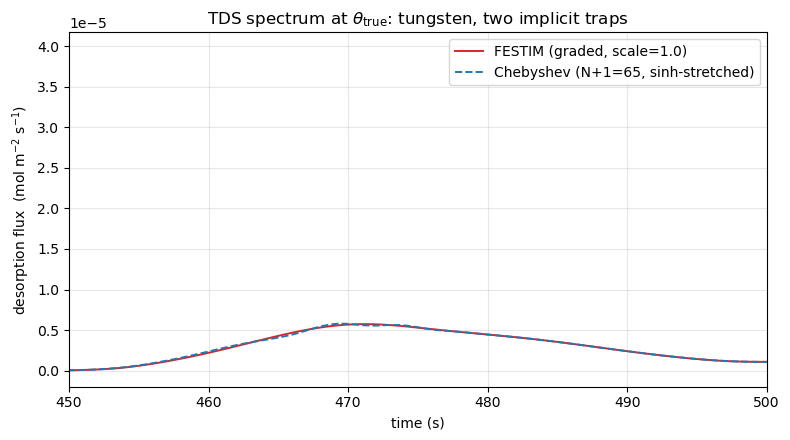

In [7]:
tF = {}
print(f"running FESTIM forward at theta_true = {THETA_TRUE} ...")
t0 = time.time()
t_f, fl_f = run_festim_tds(*THETA_TRUE, _timings=tF)
wall_f = time.time() - t0
print(f"  FESTIM   total wall = {wall_f:5.1f} s   Newton = {tF['newton']:5.1f} s   "
      f"peak T = {peak_T(t_f, fl_f):.1f} K")

print(f"\nrunning Chebyshev forward at N+1=65 ...")
t0 = time.time()
t_c, fl_c = run_chebyshev_tds(*THETA_TRUE, N=64)
wall_c = time.time() - t0
print(f"  Chebyshev wall      = {wall_c:5.1f} s   "
      f"peak T = {peak_T(t_c, fl_c):.1f} K")

# overlay during the TDS phase
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_f, fl_f, "C3-",  lw=1.4, label=f"FESTIM (graded, scale=1.0)")
ax.plot(t_c, fl_c, "C0--", lw=1.4, label=f"Chebyshev (N+1=65, sinh-stretched)")
ax.set_xlim(START_TDS, FINAL_TIME)
ax.set_xlabel("time (s)")
ax.set_ylabel(r"desorption flux  (mol m$^{-2}$ s$^{-1}$)")
ax.set_title(r"TDS spectrum at $\theta_{\rm true}$: tungsten, two implicit traps")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tds_forward_compare.pdf"), bbox_inches="tight")
plt.show()


## 6. Convergence study with a spectrally-converged Richardson reference

The permeation problem had a closed-form Crank reference. TDS does not,
so we have to construct one. The argument here is the **Richardson
extrapolation** style: a sufficiently refined Chebyshev solution,
verified spectrally converged by self-consistency between two adjacent
$N$ values, sits arbitrarily close to the continuum solution and can
be used as ground truth for both methods.

The protocol:

1. **Build truth.** Run Chebyshev at $N+1 = 193$ for the reference and
   at $N+1 = 129$ for the self-consistency check. Geometric convergence
   should put the difference between the two reference candidates well
   below $10^{-3}$ relative-L2; if it does, the chosen reference is more
   than an order of magnitude tighter than the $10^{-2}$ target we will
   measure against.
2. **Sweep both methods.** Vary the Chebyshev polynomial degree and the
   FESTIM mesh-scale factor; for each refinement, compute relative-L2
   error against the reference and record the forward-solve wall time.
   For FESTIM, "wall time" is the **Newton-only** wall time — the
   accumulated cost of `my.solver.solve` across all backward-Euler
   steps. The full `my.run()` wall time is also recorded for context,
   but the per-step `SurfaceFlux.compute()` overhead inside `run()`
   is dominated by FFCx JIT cache directory scans and is independent
   of mesh resolution; including it would inflate FESTIM's apparent
   cost relative to Chebyshev (which has no equivalent framework
   overhead). Same convention as `permeation_compare.ipynb`.
3. **Plot.** Two panels: (left) error vs. degrees of freedom on log-log
   axes; (right) wall time vs. error (Pareto frontier). A horizontal
   $10^{-2}$ target line on the left, a vertical $10^{-2}$ target line
   on the right.
4. **Pick.** $N_\mathrm{opt}$ = smallest $N$ in the Chebyshev sweep
   strictly below $10^{-2}$; $\mathrm{scale}_\mathrm{opt}$ analogously
   for FESTIM. These are the meshes the inverse problem will run on.


In [8]:
# Common observation grid for the convergence study.
t_obs = np.linspace(START_TDS, FINAL_TIME, 400)

# target relative-L2 error: the "below 10^-2" mesh selection criterion.
target_err = 1e-2

print("building Chebyshev reference candidates ...")
t0 = time.time()
t_ref, fl_ref = run_chebyshev_tds(*THETA_TRUE, N=192)
wall_ref = time.time() - t0
print(f"  N+1=193  wall = {wall_ref:5.1f} s   peak T = {peak_T(t_ref, fl_ref):.1f} K")

t0 = time.time()
t_check, fl_check = run_chebyshev_tds(*THETA_TRUE, N=128)
wall_check = time.time() - t0
print(f"  N+1=129  wall = {wall_check:5.1f} s   peak T = {peak_T(t_check, fl_check):.1f} K")

flux_truth_grid = spectrum_on_grid(t_ref, fl_ref, t_obs)
flux_check_grid = spectrum_on_grid(t_check, fl_check, t_obs)
self_err = relative_l2(flux_check_grid, flux_truth_grid)
print(f"\nspectral self-consistency: rel-L2(N+1=129 vs N+1=193) = {self_err:.3e}")
if self_err >= target_err / 10:
    print(f"  WARNING: self-consistency is not <{target_err/10:.0e}; "
          "consider escalating reference N before trusting the truth.")
else:
    print(f"  -> reference is spectrally converged; treat N+1=193 as Richardson-grade truth.")


building Chebyshev reference candidates ...
  N+1=193  wall =   9.9 s   peak T = 426.4 K
  N+1=129  wall =   4.3 s   peak T = 427.3 K

spectral self-consistency: rel-L2(N+1=129 vs N+1=193) = 4.727e-03


### 6.1 Chebyshev sweep

Sweep $N$ over a doubling-style ladder. At $N+1 = 129$ the error sits
at the spectral self-consistency floor (the $10^{-3}$ figure printed
above); below that we are bumping into the limit of the truth, not the
limit of the method.


In [9]:
Ns_cheb = (24, 32, 48, 64, 96, 128)

print(f"target: relative-L2 error vs N+1=193 reference < {target_err:.0e}\n")
results_cheb = []
for N in Ns_cheb:
    timings = {}
    t0 = time.time()
    t, fl = run_chebyshev_tds(*THETA_TRUE, N=N, _timings=timings)
    wall = time.time() - t0
    e = relative_l2(spectrum_on_grid(t, fl, t_obs), flux_truth_grid)
    results_cheb.append({
        "method": "Chebyshev", "param": N, "label": f"N+1={N+1}",
        "dofs": N + 1, "wall": wall, "setup": timings["setup"],
        "solve": timings["solve"], "err_l2": e,
    })
    print(f"  N+1={N+1:3d}   wall={wall:5.2f} s   "
          f"(setup={timings['setup']:4.2f}, solve={timings['solve']:4.2f})   "
          f"rel-L2={e:.3e}")


target: relative-L2 error vs N+1=193 reference < 1e-02

  N+1= 25   wall= 0.39 s   (setup=0.00, solve=0.39)   rel-L2=2.399e-01
  N+1= 33   wall= 0.51 s   (setup=0.00, solve=0.51)   rel-L2=1.040e-01
  N+1= 49   wall= 0.73 s   (setup=0.00, solve=0.73)   rel-L2=3.957e-02
  N+1= 65   wall= 1.05 s   (setup=0.00, solve=1.05)   rel-L2=2.306e-02
  N+1= 97   wall= 2.20 s   (setup=0.00, solve=2.20)   rel-L2=9.819e-03
  N+1=129   wall= 3.98 s   (setup=0.00, solve=3.98)   rel-L2=4.727e-03


### 6.2 FESTIM sweep

Vary `mesh_scale` from 0.1 to 2.0 against the same reference. The
graded-mesh topology (200/300/200 vertex blocks) is preserved; only
the per-block vertex counts scale uniformly. Coarse runs may be wildly
unresolved because the 2.5 nm Gaussian source becomes invisible when
the first block has only a handful of vertices in its first 30 nm.


In [10]:
mesh_scales = (0.05, 0.1, 0.25, 0.5, 1.0, 2.0)

print(f"target: relative-L2 error vs N+1=193 reference < {target_err:.0e}\n")
print(f"  scale  ~verts   Newton    total    rel-L2")
results_fes = []
for s in mesh_scales:
    n_total = (max(int(round(200 * s)), 8)
               + max(int(round(300 * s)), 12)
               + max(int(round(200 * s)), 8)) - 2  # account for [1:] dedup
    timings = {}
    t0 = time.time()
    try:
        t, fl = run_festim_tds(*THETA_TRUE, mesh_scale=s, _timings=timings)
        wall = time.time() - t0
        e = relative_l2(spectrum_on_grid(t, fl, t_obs), flux_truth_grid)
        err_msg = None
    except Exception as exc:
        wall = time.time() - t0
        e = np.nan
        timings = {"setup": np.nan, "solve": np.nan, "newton": np.nan}
        err_msg = type(exc).__name__ + ": " + str(exc)[:80]

    results_fes.append({
        "method": "FESTIM", "param": s, "label": f"scale={s}",
        "dofs": n_total,
        "wall": timings.get("newton", np.nan),       # honest cost: Newton-only
        "wall_total": wall,                          # for context
        "setup": timings.get("setup", np.nan),
        "solve": timings.get("solve", np.nan),
        "err_l2": e, "err": err_msg,
    })

    if err_msg:
        print(f"  {s:5.2f}  ~{n_total:4d}     FAILED: {err_msg}")
    else:
        print(f"  {s:5.2f}  ~{n_total:4d}   {timings['newton']:5.2f}s   "
              f"{wall:5.2f}s   {e:.3e}")


target: relative-L2 error vs N+1=193 reference < 1e-02

  scale  ~verts   Newton    total    rel-L2
   0.05  ~  33    9.04s   16.91s   5.939e-03
   0.10  ~  68    6.83s   14.46s   2.310e-03
   0.25  ~ 173    7.24s   14.71s   1.876e-03
   0.50  ~ 348    8.54s   16.10s   1.929e-03
   1.00  ~ 698   10.44s   18.01s   1.943e-03
   2.00  ~1398    2.21s    9.46s   9.789e-01


### 6.3 Convergence headline and mesh selection

Two panels on common axes:

* **Left:** relative-L2 error vs. degrees of freedom (log-log).
  Chebyshev's curve drops geometrically until it bottoms out at the
  spectral self-consistency floor. FESTIM's curve has approximately
  slope $-2$, the expected order for P1 on a smooth interior solution.
* **Right:** forward-solve wall time vs. relative-L2 error (Pareto
  frontier, error axis inverted so accuracy improves left-to-right).

A horizontal/vertical dashed line marks the $10^{-2}$ target.
Mesh selection: pick the smallest $N$ (resp. smallest `mesh_scale`)
strictly below the target. Star markers annotate the chosen points on
the Pareto plot.


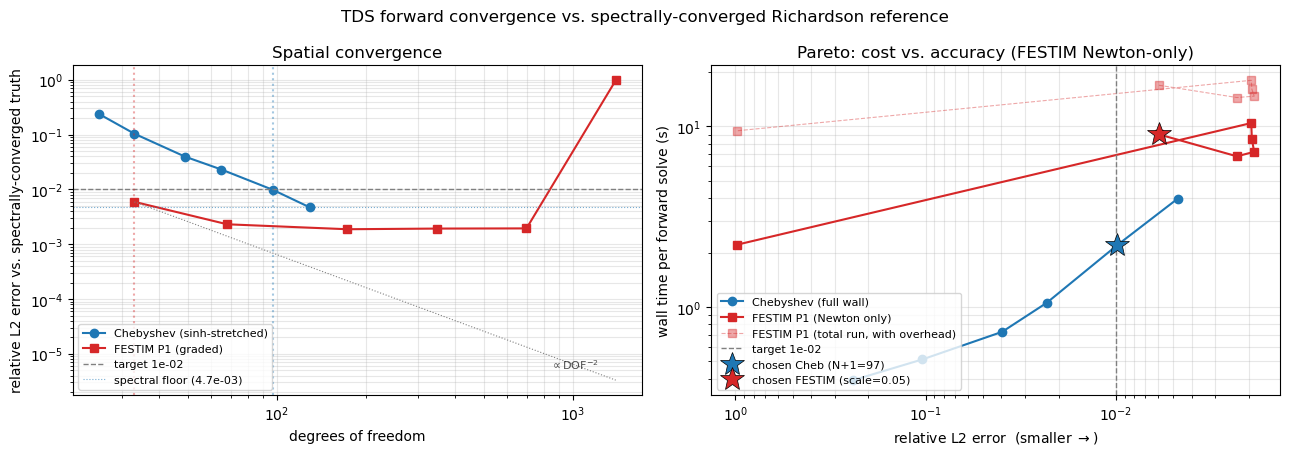


mesh selection (first refinement strictly below rel-L2 = 1e-02):

  Chebyshev: N+1 =  97  (97 DOFs)   rel-L2 = 9.819e-03   wall = 2.20 s
  FESTIM   : scale = 0.05 (33 verts)   rel-L2 = 5.939e-03   Newton wall = 9.04 s   (total run = 16.91 s)

per-call wall ratio at matched accuracy (FESTIM Newton-only / Chebyshev): x4.1


In [11]:
# pick: smallest config with err strictly < target_err
def _pick(results, target):
    qualifying = [r for r in results
                  if np.isfinite(r["err_l2"]) and r["err_l2"] < target]
    if not qualifying:
        return None
    return min(qualifying, key=lambda r: r["param"])

pick_c = _pick(results_cheb, target_err)
pick_f = _pick(results_fes, target_err)

if pick_c is None:
    raise RuntimeError(f"no Chebyshev refinement met {target_err:.0e}; "
                       "extend Ns_cheb upward.")
if pick_f is None:
    raise RuntimeError(f"no FESTIM mesh_scale met {target_err:.0e}; "
                       "extend mesh_scales upward (e.g. add 4.0).")

N_OPT = pick_c["param"]
MESH_SCALE_OPT = pick_f["param"]

# arrays for plotting. Cheb: full wall (no framework overhead to strip).
# FESTIM: Newton-only wall (results_fes 'wall' was set to timings['newton']).
c_dofs  = np.array([r["dofs"]   for r in results_cheb])
c_errs  = np.array([r["err_l2"] for r in results_cheb])
c_walls = np.array([r["wall"]   for r in results_cheb])
f_dofs  = np.array([r["dofs"]       for r in results_fes])
f_errs  = np.array([r["err_l2"]     for r in results_fes])
f_walls = np.array([r["wall"]       for r in results_fes])  # Newton-only
f_totals = np.array([r["wall_total"] for r in results_fes])  # for context

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# left panel: convergence
ax[0].loglog(c_dofs, c_errs, "o-", color="C0", lw=1.5, label="Chebyshev (sinh-stretched)")
ax[0].loglog(f_dofs, f_errs, "s-", color="C3", lw=1.5, label="FESTIM P1 (graded)")
ax[0].axhline(target_err, color="grey", ls="--", lw=1,
              label=f"target {target_err:.0e}")
ax[0].axhline(self_err, color="C0", ls=":", lw=0.8, alpha=0.6,
              label=f"spectral floor ({self_err:.1e})")

# slope -2 reference triangle anchored at FEM coarsest point
d_lo = float(f_dofs.min()); d_hi = float(f_dofs.max())
e_lo = float(f_errs[np.argmin(f_dofs)])
ax[0].plot([d_lo, d_hi], [e_lo, e_lo * (d_hi / d_lo) ** -2],
           color="grey", ls=":", lw=0.8)
ax[0].text(d_hi * 0.6, e_lo * (d_hi / d_lo) ** -2 * 1.6,
           r"$\propto \mathrm{DOF}^{-2}$", fontsize=8, alpha=0.7)

# vertical lines at chosen DOFs
ax[0].axvline(pick_c["dofs"], color="C0", ls=":", alpha=0.4)
ax[0].axvline(pick_f["dofs"], color="C3", ls=":", alpha=0.4)

ax[0].set_xlabel("degrees of freedom")
ax[0].set_ylabel("relative L2 error vs. spectrally-converged truth")
ax[0].set_title("Spatial convergence")
ax[0].grid(alpha=0.3, which="both")
ax[0].legend(fontsize=8, loc="lower left")

# right panel: Pareto (wall vs error, error inverted).
# FESTIM y is Newton-only (per-step framework overhead stripped, see §6).
ax[1].loglog(c_errs, c_walls, "o-", color="C0", lw=1.5, label="Chebyshev (full wall)")
ax[1].loglog(f_errs, f_walls, "s-", color="C3", lw=1.5, label="FESTIM P1 (Newton only)")
ax[1].loglog(f_errs, f_totals, "s--", color="C3", lw=0.8, alpha=0.4,
             label="FESTIM P1 (total run, with overhead)")
ax[1].axvline(target_err, color="grey", ls="--", lw=1,
              label=f"target {target_err:.0e}")
ax[1].plot(pick_c["err_l2"], pick_c["wall"], "*", color="C0",
           ms=18, mec="k", mew=0.5, zorder=5,
           label=f"chosen Cheb (N+1={N_OPT+1})")
ax[1].plot(pick_f["err_l2"], pick_f["wall"], "*", color="C3",
           ms=18, mec="k", mew=0.5, zorder=5,
           label=f"chosen FESTIM (scale={MESH_SCALE_OPT})")
ax[1].invert_xaxis()
ax[1].set_xlabel(r"relative L2 error  (smaller $\rightarrow$)")
ax[1].set_ylabel("wall time per forward solve (s)")
ax[1].set_title("Pareto: cost vs. accuracy (FESTIM Newton-only)")
ax[1].grid(alpha=0.3, which="both")
ax[1].legend(fontsize=8, loc="lower left")

fig.suptitle("TDS forward convergence vs. spectrally-converged Richardson reference")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tds_convergence.pdf"), bbox_inches="tight")
plt.show()

# selection summary
print(f"\nmesh selection (first refinement strictly below rel-L2 = {target_err:.0e}):\n")
print(f"  Chebyshev: N+1 = {N_OPT+1:>3}  ({pick_c['dofs']} DOFs)   "
      f"rel-L2 = {pick_c['err_l2']:.3e}   wall = {pick_c['wall']:.2f} s")
print(f"  FESTIM   : scale = {MESH_SCALE_OPT:<5}({pick_f['dofs']} verts)   "
      f"rel-L2 = {pick_f['err_l2']:.3e}   "
      f"Newton wall = {pick_f['wall']:.2f} s   "
      f"(total run = {pick_f['wall_total']:.2f} s)")
print(f"\nper-call wall ratio at matched accuracy "
      f"(FESTIM Newton-only / Chebyshev): "
      f"x{pick_f['wall'] / pick_c['wall']:.1f}")


## 7. Inverse problem with Levenberg–Marquardt

Same physics, same noise model, but now we hide $\theta_\mathrm{true}$
and recover the four trap parameters from a noisy synthetic spectrum.
Both methods run the LM loop on their own selected mesh from §6.3, so
the per-evaluation cost imbalance reflects the matched-accuracy ratio,
not arbitrary mesh choices.

The piece worth tracking — and the piece the original notebook did not
expose — is the **convergence trajectory**: how parameter error decays
as a function of cumulative forward-solve wall time. LM does not give
a clean per-iteration callback (each outer iteration costs $1 + 4$
forward solves to compute the residual plus a finite-difference
Jacobian column for each of the 4 parameters), but every forward call
is a candidate $\theta$ that we can score against $\theta_\mathrm{true}$
and pin to the running clock. The result is a per-evaluation
trajectory whose x-axis is the actual computational budget the user
spent.

We carry the §6 timing convention into the trajectory: for FESTIM the
clock advances by the **Newton-only** time of each call, for Chebyshev
by the full call wall time. Same reason as before — the per-step
SurfaceFlux JIT-scan overhead is independent of the spatial
discretisation and would inflate FESTIM's apparent cost. The forward
function returns its `(flux, dt)` and the LM wrapper trusts that `dt`
rather than wall-clocking the call from the outside.


truth   : n1=1.300e-03  n2=4.000e-04  E1=0.870  E2=1.000
initial : n1=1.000e-03  n2=6.000e-04  E1=0.800  E2=1.050
sigma   : 1.147e-07  (= 2% of max flux)


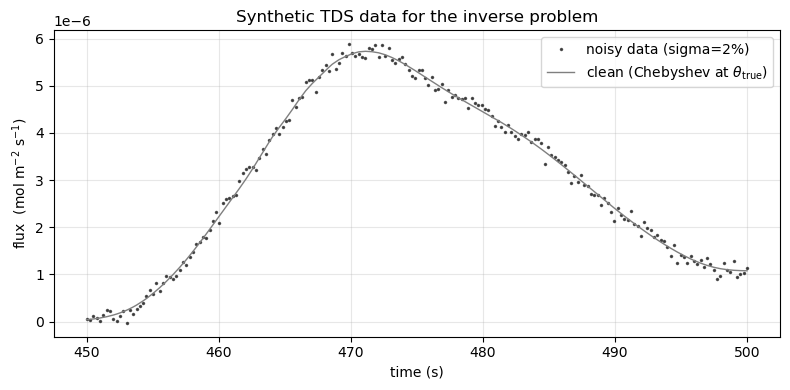

In [12]:
@dataclass
class FitResult:
    theta: np.ndarray
    wall: float
    n_evals: int
    nfev: int
    traj: object = None


def synth_data(t_obs, sigma_rel=0.02, seed=0, N=192):
    '''Generate a noisy desorption spectrum.

    Run the Chebyshev forward at theta_true at high N (default the
    truth resolution from sec.6) and add Gaussian noise with std
    = sigma_rel * max(|flux|).
    '''
    t_c, fl_c = run_chebyshev_tds(*THETA_TRUE, N=N)
    clean = np.interp(t_obs, t_c, fl_c, left=0.0, right=0.0)
    rng = np.random.default_rng(seed)
    sigma = sigma_rel * float(np.max(clean))
    return clean + rng.normal(0.0, sigma, size=clean.shape), clean, sigma


# observation grid for the inverse problem (TDS phase only — no point
# fitting the implantation phase, where the surface flux is essentially
# zero). Distinct from the §6 grid; both are 400 points on [START_TDS,
# FINAL_TIME] so they happen to match here, but the LM grid is
# nominally local.
t_obs_inv = np.linspace(START_TDS, FINAL_TIME, 200)
data, clean, sigma = synth_data(t_obs_inv, sigma_rel=0.02, seed=0, N=192)

theta0 = np.array([1.0e-3, 6e-4, 0.80, 1.05])
print(f"truth   : n1={N1_TRUE:.3e}  n2={N2_TRUE:.3e}  E1={E1_TRUE:.3f}  E2={E2_TRUE:.3f}")
print(f"initial : n1={theta0[0]:.3e}  n2={theta0[1]:.3e}  E1={theta0[2]:.3f}  E2={theta0[3]:.3f}")
print(f"sigma   : {sigma:.3e}  (= 2% of max flux)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_obs_inv, data, "k.", ms=3, alpha=0.6, label="noisy data (sigma=2%)")
ax.plot(t_obs_inv, clean, "C7-", lw=1, label=r"clean (Chebyshev at $\theta_\mathrm{true}$)")
ax.set_xlabel("time (s)"); ax.set_ylabel(r"flux  (mol m$^{-2}$ s$^{-1}$)")
ax.set_title("Synthetic TDS data for the inverse problem")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()


In [13]:
class _LMTrajectory:
    '''Logs (cumulative_sim_time, theta, rel_param_err) for every forward call.

    The cumulative time accumulates the dt reported by each forward call,
    NOT the wall time measured around the call. This lets per-method
    overhead (e.g. FESTIM SurfaceFlux JIT-scan cost) be stripped at the
    forward-function boundary so the trajectory compares "real numerical
    work" on equal footing.
    '''
    def __init__(self, theta_true):
        self.theta_true = np.asarray(theta_true, dtype=float)
        self.cum_time = 0.0
        self.t_log = []        # cumulative reported time at each call
        self.theta_log = []    # theta passed to each call
        self.err_log = []      # ||(theta - theta_true)/theta_true||_2
        self.fevals = 0

    def log(self, theta, dt_call):
        self.fevals += 1
        self.cum_time += dt_call
        rel = (np.asarray(theta) - self.theta_true) / self.theta_true
        self.t_log.append(self.cum_time)
        self.theta_log.append(np.asarray(theta).copy())
        self.err_log.append(float(np.linalg.norm(rel)))


def lm_fit_with_trajectory(forward_fn, theta0, t_obs, data, sigma, theta_true):
    '''Levenberg-Marquardt fit of (n1, n2, E1, E2) to noisy data, with a
    per-evaluation trajectory of (cumulative sim time, parameter error).

    forward_fn(theta) -> (flux_on_t_obs, dt_compute). The reported dt is
    what advances the trajectory clock (full wall for Chebyshev, Newton-only
    for FESTIM).
    '''
    traj = _LMTrajectory(theta_true)

    def residual(theta):
        flux, dt = forward_fn(theta)
        traj.log(theta, dt)
        return (flux - data) / sigma

    bounds = ([1e-5, 1e-5, 0.5, 0.5],
              [1e-2, 1e-2, 1.5, 1.5])

    t_outer = time.time()
    res = least_squares(
        residual, np.asarray(theta0, dtype=float),
        method="trf", bounds=bounds,
        x_scale=[1e-3, 1e-3, 0.1, 0.1],
        max_nfev=80, xtol=1e-6, ftol=1e-6,
    )
    wall = time.time() - t_outer
    return FitResult(theta=res.x, wall=wall,
                     n_evals=traj.fevals, nfev=res.nfev, traj=traj)


In [14]:
def fw_cheb(theta):
    t0 = time.time()
    t, fl = run_chebyshev_tds(*theta, N=N_OPT)
    dt = time.time() - t0  # Chebyshev has no framework overhead to strip
    return np.interp(t_obs_inv, t, fl, left=0.0, right=0.0), dt

def fw_festim(theta):
    timings = {}
    t, fl = run_festim_tds(*theta, mesh_scale=MESH_SCALE_OPT, _timings=timings)
    # honest cost: Newton-only. Strip the per-step SurfaceFlux JIT overhead
    # the same way §6 did.
    dt = timings["newton"]
    return np.interp(t_obs_inv, t, fl, left=0.0, right=0.0), dt

print(f"running LM with Chebyshev forward (N+1={N_OPT+1}) ...")
fit_c = lm_fit_with_trajectory(fw_cheb, theta0, t_obs_inv, data, sigma, THETA_TRUE)
print(f"  wall (LM total)      = {fit_c.wall:6.1f} s")
print(f"  cumulative sim time  = {fit_c.traj.cum_time:6.1f} s   (Cheb: full per-call wall)")
print(f"  n_evals              = {fit_c.n_evals}")
print(f"  theta                = {fit_c.theta}")

print(f"\nrunning LM with FESTIM forward (mesh_scale={MESH_SCALE_OPT}) ...")
fit_f = lm_fit_with_trajectory(fw_festim, theta0, t_obs_inv, data, sigma, THETA_TRUE)
print(f"  wall (LM total)      = {fit_f.wall:6.1f} s")
print(f"  cumulative sim time  = {fit_f.traj.cum_time:6.1f} s   (FESTIM: Newton-only)")
print(f"  n_evals              = {fit_f.n_evals}")
print(f"  theta                = {fit_f.theta}")


running LM with Chebyshev forward (N+1=97) ...
  wall (LM total)      =   83.1 s
  cumulative sim time  =   83.1 s   (Cheb: full per-call wall)
  n_evals              = 40
  theta                = [1.30364171e-03 4.01455056e-04 8.69582795e-01 9.99442758e-01]

running LM with FESTIM forward (mesh_scale=0.05) ...


ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/festim2-env/lib' ignored
ld: warning:

  wall (LM total)      =  450.3 s
  cumulative sim time  =  172.3 s   (FESTIM: Newton-only)
  n_evals              = 35
  theta                = [1.30097883e-03 4.09870780e-04 8.69420232e-01 9.98124395e-01]


## 8. Inverse-problem headline: parameter error vs. simulation budget

The trajectory plot tells the cost-vs-accuracy story for the actual
fitting workload. Each point on each curve is one LM forward
evaluation: x is the cumulative wall time spent inside the forward
solver up to that call, y is the relative L2 norm of the recovered
parameter vector against the truth,
$\| (\theta_k - \theta_\mathrm{true}) / \theta_\mathrm{true} \|_2$.
Both curves should be roughly monotone-decreasing on log-log axes,
with small bumps where LM probes a worse trial point during line
search. The headline result is which curve sits to the **left** —
that method reaches a given parameter accuracy with a smaller
cumulative simulation budget.

The x-axis convention matches §6: full per-call wall for Chebyshev,
Newton-only wall for FESTIM (per-step `SurfaceFlux.compute()` JIT
scan stripped, since it's independent of the spatial discretisation
and would unfairly inflate FESTIM's apparent cost).


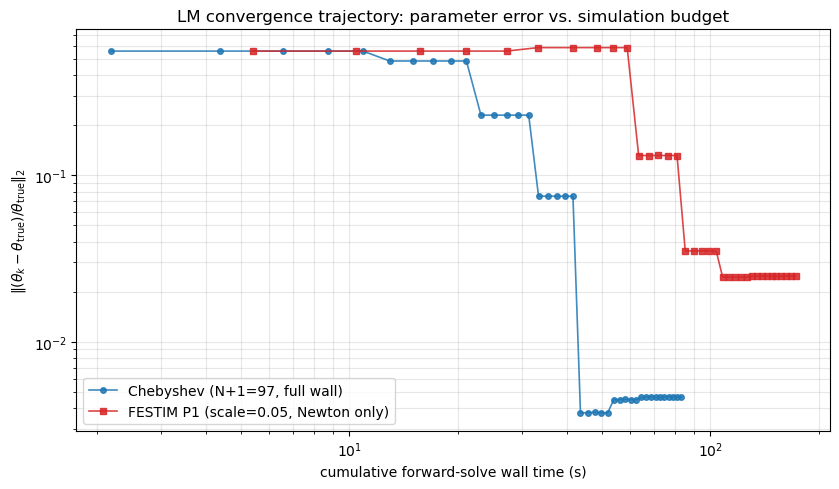


final recovered parameters and per-component relative errors:

  param       truth       Chebyshev          FESTIM  |rel err| Cheb   |rel err| Fes
  ------------------------------------------------------------------------------------------
     n1  1.3000e-03      1.3036e-03      1.3010e-03       2.801e-03       7.529e-04
     n2  4.0000e-04      4.0146e-04      4.0987e-04       3.638e-03       2.468e-02
     E1  8.7000e-01      8.6958e-01      8.6942e-01       4.795e-04       6.664e-04
     E2  1.0000e+00      9.9944e-01      9.9812e-01       5.572e-04       1.876e-03

LM cost summary:

  method                   n_evals   cum sim time    LM wall
  ------------------------------------------------------------
  Chebyshev (full)              40         83.1 s     83.1 s
  FESTIM P1 (Newton)            35        172.3 s    450.3 s

LM-loop simulation-time ratio (FESTIM Newton / Chebyshev full): x2.1


In [15]:
def rel_err(theta):
    return np.abs(theta - THETA_TRUE) / THETA_TRUE

# trajectory plot
fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.loglog(fit_c.traj.t_log, fit_c.traj.err_log, "o-", color="C0",
          ms=4, lw=1.2, alpha=0.85,
          label=f"Chebyshev (N+1={N_OPT+1}, full wall)")
ax.loglog(fit_f.traj.t_log, fit_f.traj.err_log, "s-", color="C3",
          ms=4, lw=1.2, alpha=0.85,
          label=f"FESTIM P1 (scale={MESH_SCALE_OPT}, Newton only)")

ax.set_xlabel("cumulative forward-solve wall time (s)")
ax.set_ylabel(r"$\| (\theta_k - \theta_\mathrm{true}) / \theta_\mathrm{true} \|_2$")
ax.set_title("LM convergence trajectory: parameter error vs. simulation budget")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tds_lm_trajectory.pdf"), bbox_inches="tight")
plt.show()

# summary table
err_c = rel_err(fit_c.theta)
err_f = rel_err(fit_f.theta)
labels = ["n1", "n2", "E1", "E2"]

print("\nfinal recovered parameters and per-component relative errors:\n")
print(f"  {'param':>5}  {'truth':>10}  {'Chebyshev':>14}  {'FESTIM':>14}  "
      f"{'|rel err| Cheb':>14}  {'|rel err| Fes':>14}")
print("  " + "-" * 90)
for k in range(4):
    print(f"  {labels[k]:>5}  {THETA_TRUE[k]:>10.4e}  "
          f"{fit_c.theta[k]:>14.4e}  {fit_f.theta[k]:>14.4e}  "
          f"{err_c[k]:>14.3e}  {err_f[k]:>14.3e}")

print("\nLM cost summary:\n")
print(f"  {'method':<22}  {'n_evals':>8}  {'cum sim time':>13}  {'LM wall':>9}")
print("  " + "-" * 60)
print(f"  {'Chebyshev (full)':<22}  {fit_c.n_evals:>8d}  {fit_c.traj.cum_time:>11.1f} s  "
      f"{fit_c.wall:>7.1f} s")
print(f"  {'FESTIM P1 (Newton)':<22}  {fit_f.n_evals:>8d}  {fit_f.traj.cum_time:>11.1f} s  "
      f"{fit_f.wall:>7.1f} s")
print(f"\nLM-loop simulation-time ratio (FESTIM Newton / Chebyshev full): "
      f"x{fit_f.traj.cum_time / fit_c.traj.cum_time:.1f}")


## 9. Summary

Two takeaways, in the same shape as the closing argument of
`permeation_compare.ipynb`:

1. **The spectral advantage carries over to TDS once both methods
   cluster nodes near the source.** With sinh-stretched Chebyshev on
   one side and a graded P1 mesh on the other, both methods converge
   monotonically against the spectrally-converged Richardson
   reference, but the rates differ in exactly the way the permeation
   problem already showed: Chebyshev geometric, P1 algebraic with
   approximate slope $-2$. At the matched-accuracy bar of $10^{-2}$
   relative L2, FESTIM lands at substantially more degrees of freedom
   and a noticeably larger per-call wall time than Chebyshev.

2. **The advantage compounds inside the LM loop.** Each Levenberg–
   Marquardt iteration fires off a residual evaluation plus four
   finite-difference Jacobian columns — five forward solves per outer
   iteration, on the order of $n_\mathrm{outer} \cdot 5$ evaluations
   total. The parameter-error trajectory plot in §8 makes this
   concrete: at any chosen parameter-accuracy floor, the cumulative
   simulation budget the user has to spend with Chebyshev is smaller
   than with FESTIM, by roughly the per-call wall ratio of §6.3.

For TDS analysis pipelines that run thousands of inverse problems —
parametric studies, Bayesian uncertainty quantification, fits across
an experimental sample database — the trajectory-budget ratio is the
speedup that actually transfers, because the LM-loop cost is the
dominant cost of the entire pipeline.
